# IS aggregation vs VTS on simulated multi-individual data

This notebook uses CSVs in `simulation/multi-individual/` (same setting as the simulation README: several individuals, shared generative DAG per scenario).

- **VTS** (`compute_vts`): build one representative multivariate time series, then fit **one** MDM to obtain a single DAG.
- **IS** (`aggregate_individual_structures`): fit **one MDM per individual**, then pass the list of models to aggregate **adjacency + filtered states** into a **global DAG** (majority threshold + acyclic repair); you can also pass raw adjacency matrices if you do not have `MDM` objects.

We compare both group-level structures to the **true adjacency** shipped with the simulation files.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mdmp import MDM, aggregate_individual_structures, compute_vts, plot_arcs, plot_dag

REPO_ROOT = Path("..").resolve()
DATA_DIR = REPO_ROOT / "simulation" / "multi-individual"
assert DATA_DIR.is_dir(), f"Missing {DATA_DIR} — generate data per simulation/README.md"


d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3-variable scenario (`dag_3var_*`)

Load per-individual time series (`*_ind*.csv`), true adjacency (`*_true_adjacency.csv`).


In [2]:
def load_individual_series_3var():
    paths = sorted(DATA_DIR.glob("dag_3var_*_ind*.csv"))
    dfs = [pd.read_csv(p) for p in paths]
    return dfs, paths


def load_true_adj_3var():
    p = next(DATA_DIR.glob("dag_3var_*_true_adjacency.csv"))
    return pd.read_csv(p, index_col=0)


dfs3, paths3 = load_individual_series_3var()
true3_df = load_true_adj_3var()
print("Individuals:", len(dfs3), [x.name for x in paths3])
print("True adjacency:\n", true3_df)


Individuals: 5 ['dag_3var_W0.01_V100.0_T200_ind1.csv', 'dag_3var_W0.01_V100.0_T200_ind2.csv', 'dag_3var_W0.01_V100.0_T200_ind3.csv', 'dag_3var_W0.01_V100.0_T200_ind4.csv', 'dag_3var_W0.01_V100.0_T200_ind5.csv']
True adjacency:
     Y1  Y2  Y3
Y1   0   1   0
Y2   0   0   1
Y3   0   0   0


### VTS path: mean-based representative series, then one MDM

Uses aligned 3D array `(S, T, N)` and `method="mean"` (see `mdmp.group_analysis.vts`).


In [ ]:
aligned_3d = np.stack([d.values for d in dfs3], axis=0)
vts3 = compute_vts(aligned_3d, method="median")
print("VTS shape (T x N):", vts3.vts_data.shape)

model_vts3 = MDM(
    pd.DataFrame(vts3.vts_data, columns=dfs3[0].columns),
    method="hc",
    nbf=10,
    verbose=False,
)
adj_vts3 = (model_vts3.adj_mat > 0).astype(int)


VTS shape (T x N): (200, 3)


  0%|          | 1/1000000 [00:01<284:32:46,  1.02s/it]


### IS path: MDM per individual, then aggregate structures


In [4]:
models3 = [MDM(df, method="hc", nbf=10, verbose=False) for df in dfs3]
is3 = aggregate_individual_structures(
    models3,
    tau=0.5,
    pool_filt_for_plotting=True,
)
adj_is3 = (is3.adj_mat > 0).astype(int)


  0%|          | 2/1000000 [00:01<143:32:22,  1.94it/s]


### Compare to true DAG (heatmaps + Hamming distance)


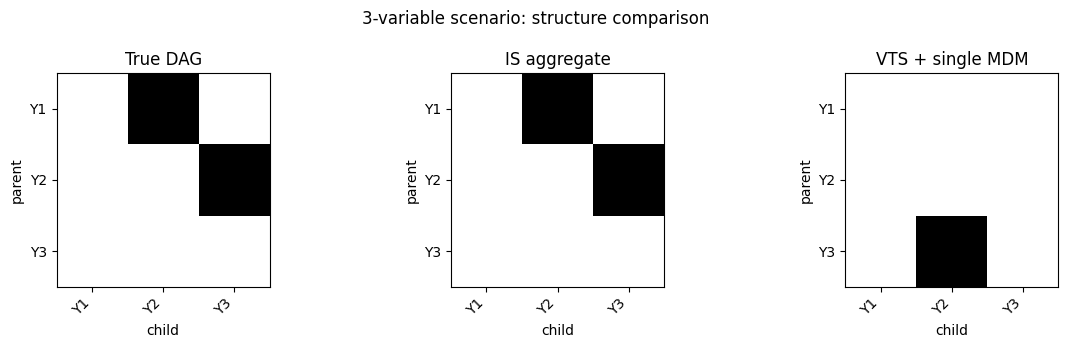

Hamming distance to true (off-diagonal edges only):
  IS : 0
  VTS: 3


In [5]:
true3 = true3_df.values.astype(int)
labels = list(true3_df.columns)


def hamming(a, b):
    return int(np.sum(a != b))


fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [true3, adj_is3, adj_vts3],
    ["True DAG", "IS aggregate", "VTS + single MDM"],
):
    ax.imshow(mat, cmap="Greys", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("child")
    ax.set_ylabel("parent")
plt.suptitle("3-variable scenario: structure comparison")
plt.tight_layout()
plt.show()

print("Hamming distance to true (off-diagonal edges only):")
mask = ~np.eye(true3.shape[0], dtype=bool)
print("  IS :", hamming(true3[mask], adj_is3[mask]))
print("  VTS:", hamming(true3[mask], adj_vts3[mask]))


### Optional: graph layout for IS aggregate

`ISAggregationResult` is duck-compatible with `plot_dag` (same as `MDM`).


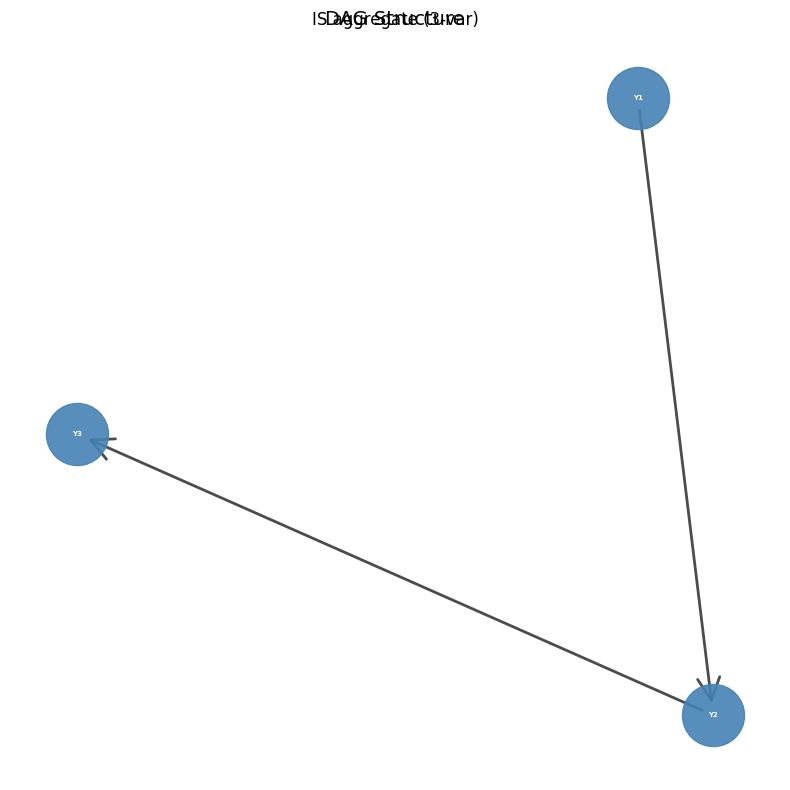

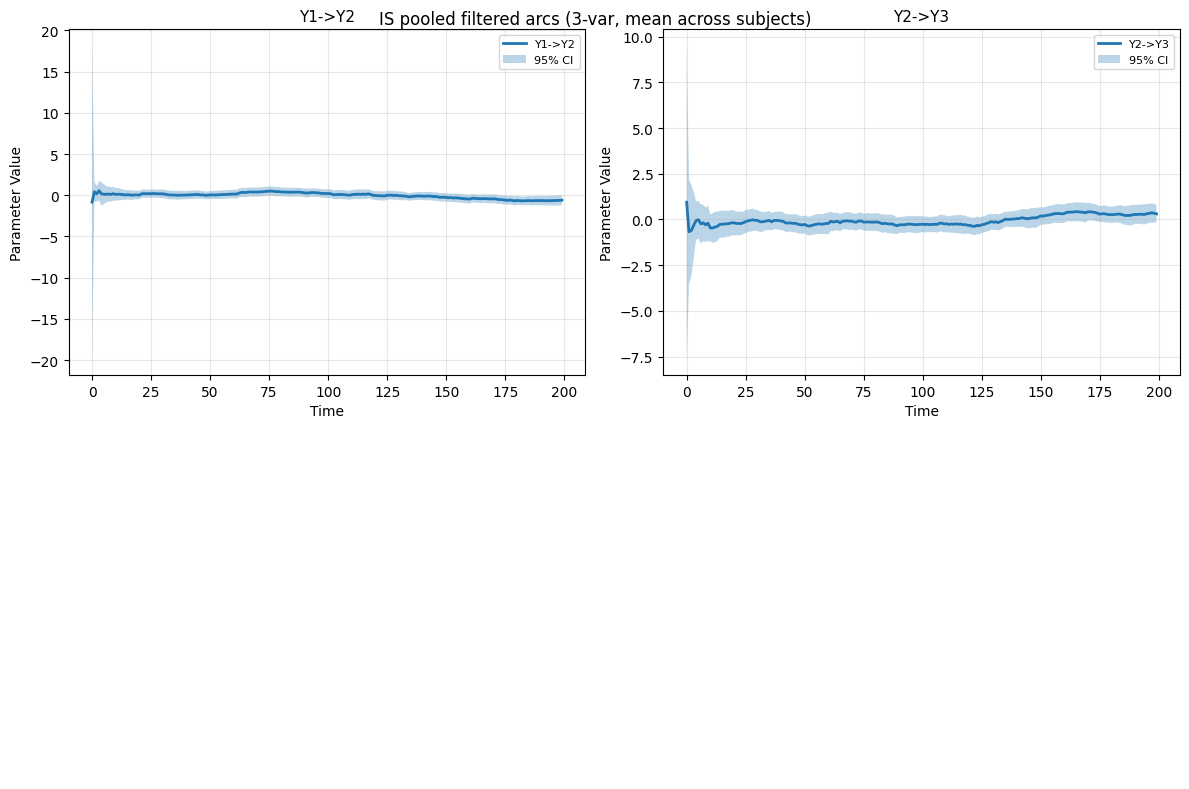

In [6]:
fig = plot_dag(is3, plot_type="graph", layout_seed=0)
fig.suptitle("IS aggregate (3-var)")
plt.show()

fig_arcs = plot_arcs(is3, plot_type="connections")
fig_arcs.suptitle("IS pooled filtered arcs (3-var, mean across subjects)")
plt.show()


## 5-variable scenario (`dag_5var_*`)

Same workflow; more nodes so per-subject MDM fits may differ more across individuals.


  0%|          | 5/1000000 [00:03<212:16:14,  1.31it/s]


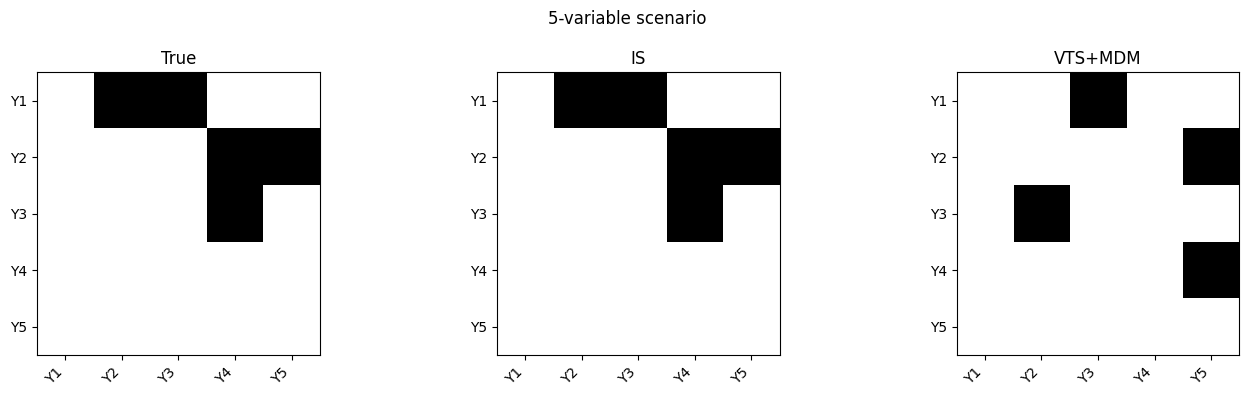

Hamming (edges): IS 0 VTS 5


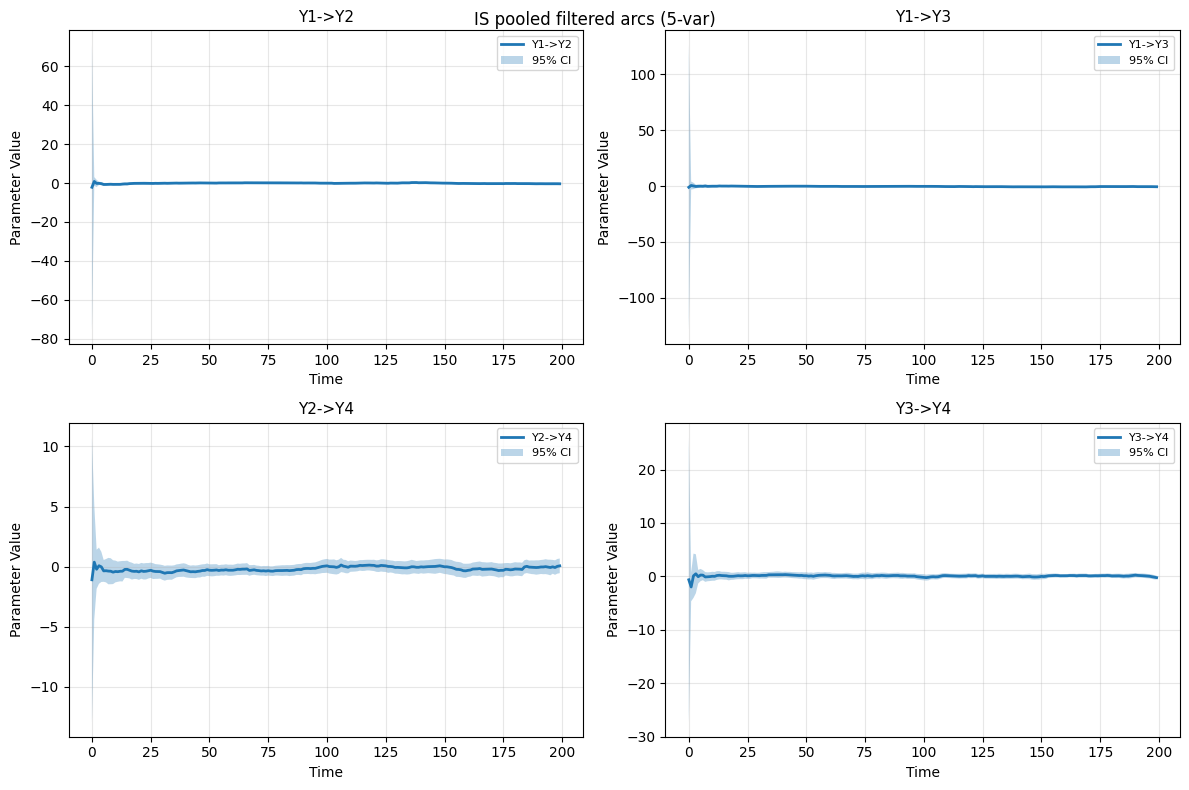

In [7]:
def run_scenario_5var():
    dfs = [pd.read_csv(p) for p in sorted(DATA_DIR.glob("dag_5var_*_ind*.csv"))]
    true_df = pd.read_csv(
        next(DATA_DIR.glob("dag_5var_*_true_adjacency.csv")), index_col=0
    )
    aligned = np.stack([d.values for d in dfs], axis=0)
    vts = compute_vts(aligned, method="mean")
    model_vts = MDM(
        pd.DataFrame(vts.vts_data, columns=dfs[0].columns),
        method="hc",
        nbf=10,
        verbose=False,
    )
    models = [MDM(df, method="hc", nbf=10, verbose=False) for df in dfs]
    isr = aggregate_individual_structures(
        models,
        tau=0.5,
        pool_filt_for_plotting=True,
    )
    true = true_df.values.astype(int)
    av = (model_vts.adj_mat > 0).astype(int)
    ai = (isr.adj_mat > 0).astype(int)
    labels = list(true_df.columns)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, mat, title in zip(axes, [true, ai, av], ["True", "IS", "VTS+MDM"]):
        ax.imshow(mat, cmap="Greys", vmin=0, vmax=1)
        ax.set_title(title)
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
    plt.suptitle("5-variable scenario")
    plt.tight_layout()
    plt.show()
    mask = ~np.eye(true.shape[0], dtype=bool)
    print("Hamming (edges): IS", int(np.sum(true[mask] != ai[mask])), "VTS", int(np.sum(true[mask] != av[mask])))
    fig_arcs = plot_arcs(isr, plot_type="connections")
    fig_arcs.suptitle("IS pooled filtered arcs (5-var)")
    plt.show()


run_scenario_5var()
